# 9. 对抗性防御算法之免费对抗性训练（2）

## 9.0 上节内容回顾与本节主要内容介绍

在上一节中，我们学习并实现了免费对抗性训练，并通过实验证明了免费对抗性训练算法能够在相较于标准训练几乎没有额外开销的情况下，实现等同于对抗性训练的防御性能。在本节中，我们将调试免费对抗性训练的参数，继续研究免费对抗性训练算法的特点。

本实验的主要内容为采用Python、PyTroch等技术，使用不同参数的免费对抗性训练算法训练模型，并进行鲁棒性测试，以此研究免费对抗性训练算法的特点。

## 9.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

import test; test_fn = test.test
from utils import load_mnist_test
from models import LeNet5


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 9.2 使用函数封装免费对抗性训练

In [2]:
def free_adversarial_training(m=5, eps=0.1):
    # 超参数
    EPOCH = 50              # 训练总epoch数
    BATCH_SIZE = 250        # 训练batch size大小
    LR = 0.001              # 初始学习率
    DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

    M = m                   # 对每个batch连续执行M次免费对抗性训练迭代
    EPS = eps               # 攻击步长
    
    assert EPOCH % M == 0, print(EPOCH, M)

    if not(os.path.exists('./data/')) or not os.listdir('./data/'):
        DOWNLOAD_MNIST = True

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 导入数据，定义数据接口
    train_dataset = torchvision.datasets.MNIST(
        root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    
    # 定义网络结构并统计模型参数
    from models import LeNet5

    cnn = LeNet5().to(device)
    print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

    # 使用Adam Optimizer
    optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

    # 设置Label Smoothing超参数
    loss_function = nn.CrossEntropyLoss()

    num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
    print('模型参数大小为：', num_params)

    # 免费对抗性训练
    train_accs = []    # 训练集对抗性准确率
    train_losses = []  # 训练集对抗性损失

    # 初始化扰动delta
    delta = torch.zeros(BATCH_SIZE, 1, 28, 28).to(device)
    
    # 训练 EPOCH / M 个轮次
    for epoch in range(round(EPOCH / M)):
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.clone().detach().requires_grad_(True)
            cnn.train()

            for i in range(M):
                l_delta = delta.clone().detach().requires_grad_(True)

                # 前向传播
                inputs1 = inputs + l_delta
                inputs2 = torch.clamp(inputs1, min=0, max=1)           

                outputs = cnn(inputs2)
                loss = loss_function(outputs, labels)

                # 梯度清零
                optimizer.zero_grad()
                if inputs.grad is not None:
                    inputs.grad.zero_()

                # 反向传播
                loss.backward()

                # 参数更新
                optimizer.step()

                # delta更新
                # 此处grad乘以batch大小是因为攻击应该使用sum作为loss function的reduction
                delta = (delta + EPS * torch.sign(n *
                         l_delta.grad)).clamp_(-EPS, EPS)

                # 数据统计
                pred = outputs.argmax(dim=-1)

                train_total += n
                train_correct += (pred == labels).sum().item()
                train_loss += loss.data.item() * n  

        train_accs.append(train_correct / train_total)
        train_losses.append(train_loss / train_total)
        logger.info(f'training epoch: {epoch}, training loss: {train_loss / train_total:.7f}, '
                    f'training acc: {100 * train_correct / train_total:.2f}%')

    # 训练过程数据展示
    plt.figure(figsize=(15, 5))

    idx = [_ for _ in range(round(EPOCH / M))]
    plt.subplot(1, 2, 1)
    plt.plot(idx, train_accs)
    plt.title('Training Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(idx, train_losses)
    plt.title('Training Loss')
    
    plt.suptitle(f'Free Adversarial Training M={m} EPS={eps}')
    plt.show()
    
    # 保存模型
    state = {
        'net': cnn.state_dict(),
        'num_epoch': epoch,
        'train_losses': train_losses,
        'train_accs': train_accs,
    }

    result_path = f'./save_model/' + str(EPOCH) + 'epoch'
    if not os.path.isdir(result_path):
        os.makedirs(result_path)
    torch.save(state, result_path + f'/mnist_lenet5_Free_AT_{M}.pth')

## 9.3 使用不同的参数M进行免费对抗性训练

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


  8264 20260207 19:12:32 training epoch: 0, training loss: 0.3806566, training acc: 88.08%
  8264 20260207 19:12:40 training epoch: 1, training loss: 0.1145988, training acc: 96.37%
  8264 20260207 19:12:48 training epoch: 2, training loss: 0.0827286, training acc: 97.33%
  8264 20260207 19:12:57 training epoch: 3, training loss: 0.0673807, training acc: 97.83%
  8264 20260207 19:13:05 training epoch: 4, training loss: 0.0573937, training acc: 98.12%
  8264 20260207 19:13:13 training epoch: 5, training loss: 0.0507154, training acc: 98.30%
  8264 20260207 19:13:22 training epoch: 6, training loss: 0.0453214, training acc: 98.50%
  8264 20260207 19:13:32 training epoch: 7, training loss: 0.0405641, training acc: 98.66%
  8264 20260207 19:13:42 training epoch: 8, training loss: 0.0359495, training acc: 98.78%
  8264 20260207 19:13:53 training epoch: 9, training loss: 0.0333009, training acc: 98.86%
  8264 20260207 19:14:03 training epoch: 10, training loss: 0.0300160, training acc: 98.98

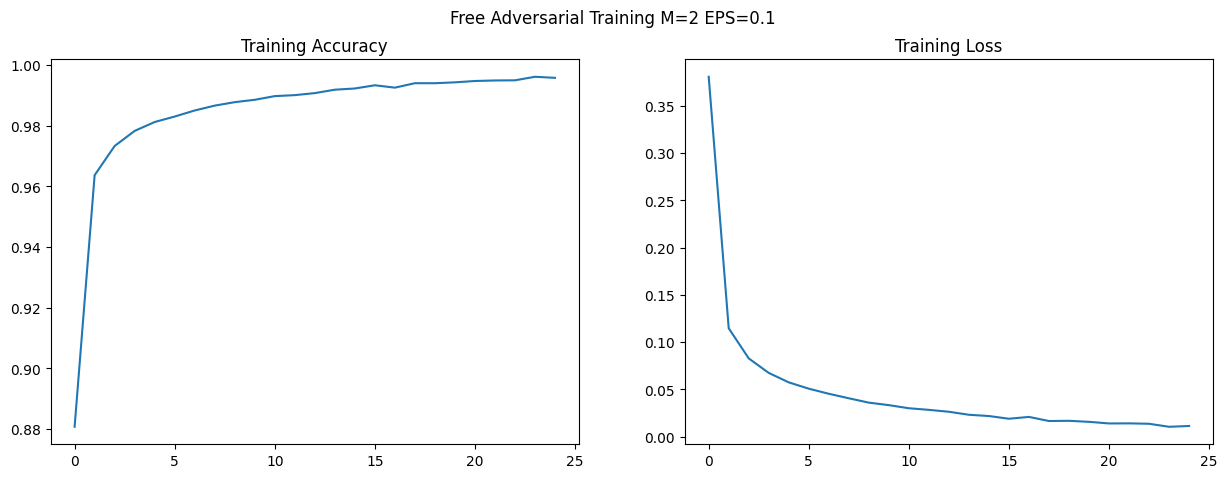

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


  8264 20260207 19:17:10 training epoch: 0, training loss: 0.2130023, training acc: 93.06%
  8264 20260207 19:17:34 training epoch: 1, training loss: 0.0976502, training acc: 96.92%
  8264 20260207 19:17:57 training epoch: 2, training loss: 0.0799921, training acc: 97.53%
  8264 20260207 19:18:24 training epoch: 3, training loss: 0.0701928, training acc: 97.87%
  8264 20260207 19:18:49 training epoch: 4, training loss: 0.0644166, training acc: 98.07%


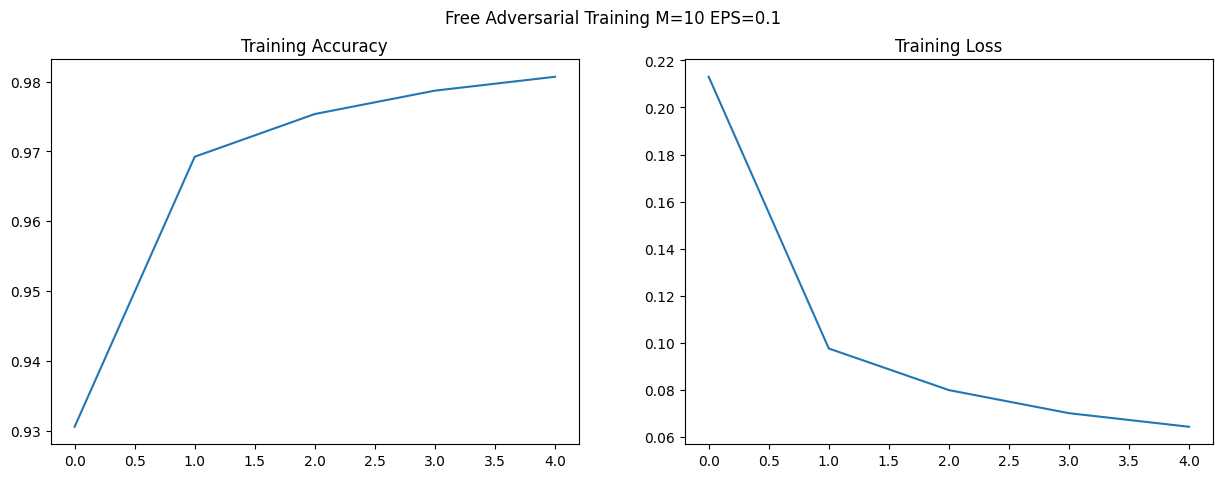

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


  8264 20260207 19:19:36 training epoch: 0, training loss: 0.0936125, training acc: 97.29%
  8264 20260207 19:20:27 training epoch: 1, training loss: 0.0460632, training acc: 98.83%


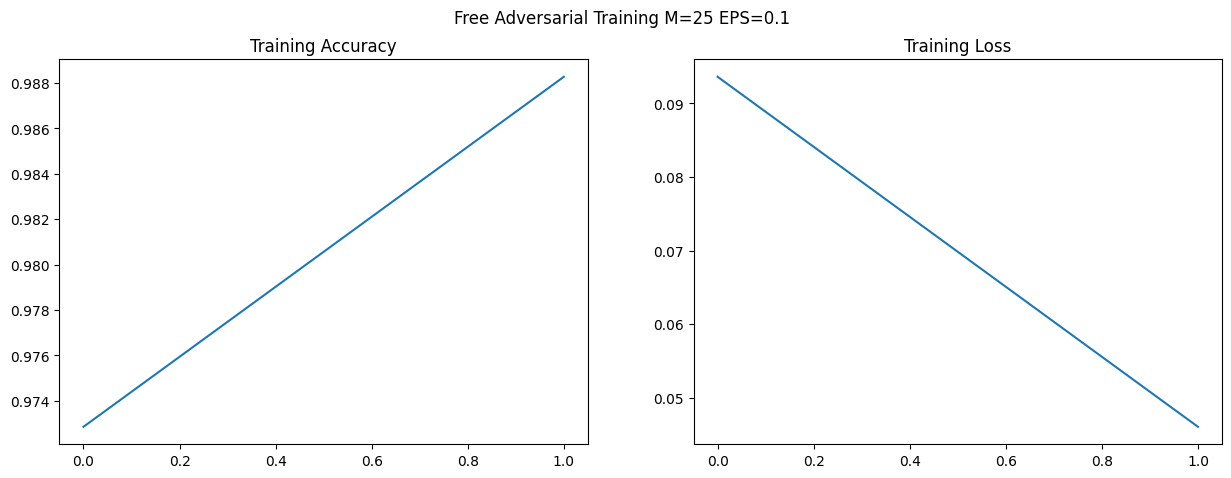

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


  8264 20260207 19:23:22 training epoch: 0, training loss: 0.0449869, training acc: 98.84%


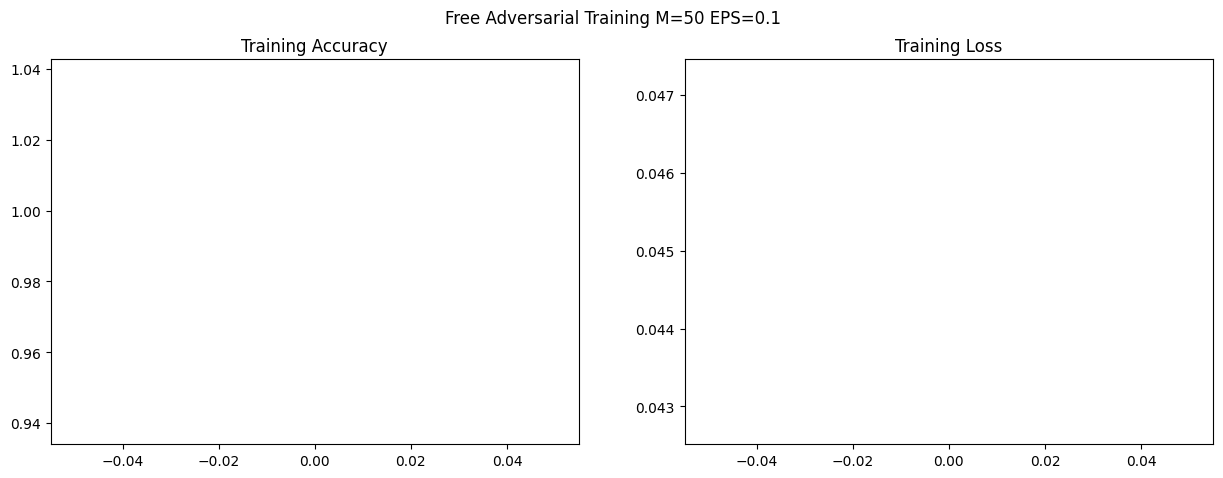

In [3]:
m_list = [2, 10, 25, 50]
for m in m_list:
    free_adversarial_training(m=m)

## 9.4 鲁棒性测试

In [4]:
from autoattack import AutoAttack

In [5]:
m_list = [2, 5, 10, 25, 50]
eps_list = [0.1, 0.2]

x, y = load_mnist_test()

for eps in eps_list:
    logger.info(f'eps: {eps}')
    for m in m_list:
        # 加载模型
        pth = f'./save_model/50epoch/mnist_lenet5_Free_AT_{m}.pth'
        state = torch.load(pth)
        cnn = LeNet5()
        cnn.load_state_dict(state['net'])
        cnn = cnn.to(device)
        cnn.eval()
        
        # 干净样本测试
        cln_acc, _ = test_fn(cnn, x, y, bs=250)
        
        # AutoAttack测试
        adversary = AutoAttack(cnn, eps=eps, verbose=False)  # 设置verbose=False以取消攻击过程中的信息输出
        x_adv = adversary.run_standard_evaluation(x, y)
        aa_acc, _ = test_fn(cnn, x_adv, y, bs=250)
        logger.info(f'm={m} Clean: {cln_acc:.2f}, AutoAttack: {aa_acc:.2f}%')

  8264 20260207 19:23:23 eps: 0.1
  8264 20260207 19:55:11 m=2 Clean: 99.07, AutoAttack: 86.48%
  8264 20260207 20:26:50 m=5 Clean: 98.90, AutoAttack: 86.50%
  8264 20260207 20:58:33 m=10 Clean: 98.80, AutoAttack: 82.89%
  8264 20260207 21:28:45 m=25 Clean: 98.27, AutoAttack: 77.72%
  8264 20260207 22:00:14 m=50 Clean: 98.40, AutoAttack: 82.29%
  8264 20260207 22:00:14 eps: 0.2
  8264 20260207 22:01:37 m=2 Clean: 99.07, AutoAttack: 1.04%
  8264 20260207 22:05:04 m=5 Clean: 98.90, AutoAttack: 7.44%
  8264 20260207 22:07:36 m=10 Clean: 98.80, AutoAttack: 4.67%
  8264 20260207 22:09:00 m=25 Clean: 98.27, AutoAttack: 1.25%
  8264 20260207 22:11:25 m=50 Clean: 98.40, AutoAttack: 3.50%


为了更充分地反映模型的鲁棒性，此处进行了更大扰动限制（ε）的AutoAttack测试，根据测试结果有以下结论：
1. 攻击扰动限制的增大会使得模型的鲁棒性有较大程度的下降。
2. 在较低扰动限制的攻击下鲁棒性领先的模型，在高扰动限制的攻击下有可能更脆弱。
3. 随着m的增大Clean的准确率会下降，这是因为重复对一个batch的样本进行学习会影响网络在整个数据集上的泛化能力。
4. 根据更大扰动的AutoAttack测试结果，调整m将带来较大的鲁棒性波动，因此在使用时可以适当地调试m的取值。